In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('matches.csv')

In [3]:
df.head()

,id,season,city,date,match_type,player_of_match,venue,team1,team2,toss_winner,toss_decision,winner,result,result_margin,target_runs,target_overs,super_over,method,umpire1,umpire2
0,335982,2007/08,Bangalore,2008-04-18,League,BB McCullum,M Chinnaswamy Stadium,Royal Challengers Bangalore,Kolkata Knight Riders,Royal Challengers Bangalore,field,Kolkata Knight Riders,runs,140.0,223.0,20.0,N,NaN,Asad Rauf,RE Koertzen
1,335983,2007/08,Chandigarh,2008-04-19,League,MEK Hussey,"Punjab Cricket Association Stadium, Mohali",Kings XI Punjab,Chennai Super Kings,Chennai Super Kings,bat,Chennai Super Kings,runs,33.0,241.0,20.0,N,NaN,MR Benson,SL Shastri
2,335984,2007/08,Delhi,2008-04-19,League,MF Maharoof,Feroz Shah Kotla,Delhi Daredevils,Rajasthan Royals,Rajasthan Royals,bat,Delhi Daredevils,wickets,9.0,130.0,20.0,N,NaN,Aleem Dar,GA Pratapkumar
3,335985,2007/08,Mumbai,2008-04-20,League,MV Boucher,Wankhede Stadium,Mumbai Indians,Royal Challengers Bangalore,Mumbai Indians,bat,Royal Challengers Bangalore,wickets,5.0,166.0,20.0,N,NaN,SJ Davis,DJ Harper
4,335986,2007/08,Kolkata,2008-04-20,League,DJ Hussey,Eden Gardens,Kolkata Knight Riders,Deccan Chargers,Deccan Chargers,bat,Kolkata Knight Riders,wickets,5.0,111.0,20.0,N,NaN,BF Bowden,K Hariharan


In [4]:
df.columns

Index(['id', 'season', 'city', 'date', 'match_type', 'player_of_match',
       'venue', 'team1', 'team2', 'toss_winner', 'toss_decision', 'winner',
       'result', 'result_margin', 'target_runs', 'target_overs', 'super_over',
       'method', 'umpire1', 'umpire2'],
      dtype='object')

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1095 entries, 0 to 1094
Data columns (total 20 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   id               1095 non-null   int64  
 1   season           1095 non-null   object 
 2   city             1044 non-null   object 
 3   date             1095 non-null   object 
 4   match_type       1095 non-null   object 
 5   player_of_match  1090 non-null   object 
 6   venue            1095 non-null   object 
 7   team1            1095 non-null   object 
 8   team2            1095 non-null   object 
 9   toss_winner      1095 non-null   object 
 10  toss_decision    1095 non-null   object 
 11  winner           1090 non-null   object 
 12  result           1095 non-null   object 
 13  result_margin    1076 non-null   float64
 14  target_runs      1092 non-null   float64
 15  target_overs     1092 non-null   float64
 16  super_over       1095 non-null   object 
 17  method        

In [6]:
df.shape

(1095, 20)

In [7]:
df.isnull().sum()

id                    0
season                0
city                 51
date                  0
match_type            0
player_of_match       5
venue                 0
team1                 0
team2                 0
toss_winner           0
toss_decision         0
winner                5
result                0
result_margin        19
target_runs           3
target_overs          3
super_over            0
method             1074
umpire1               0
umpire2               0
dtype: int64

In [8]:
df.duplicated().sum()

np.int64(0)

In [9]:
df.describe()

,id,result_margin,target_runs,target_overs
count,1.095000e+03,1076.000000,1092.000000,1092.000000
mean,9.048283e+05,17.259294,165.684066,19.759341
std,3.677402e+05,21.787444,33.427048,1.581108
min,3.359820e+05,1.000000,43.000000,5.000000
25%,5.483315e+05,6.000000,146.000000,20.000000
50%,9.809610e+05,8.000000,166.000000,20.000000
75%,1.254062e+06,20.000000,187.000000,20.000000
max,1.426312e+06,146.000000,288.000000,20.000000


In [10]:
# Fix Team Names
team_mapping = {
    'Delhi Daredevils': 'Delhi Capitals',
    'Kings XI Punjab': 'Punjab Kings',
    'Deccan Chargers': 'Sunrisers Hyderabad',
    'Rising Pune Supergiants': 'Rising Pune Supergiant',
    'Pune Warriors': 'Rising Pune Supergiant', 
    'Royal Challengers Bangalore': 'Royal Challengers Bengaluru'
}
df.replace(team_mapping, inplace=True)

Text(0.5, 1.0, 'No. of matches played on each IPL Season')

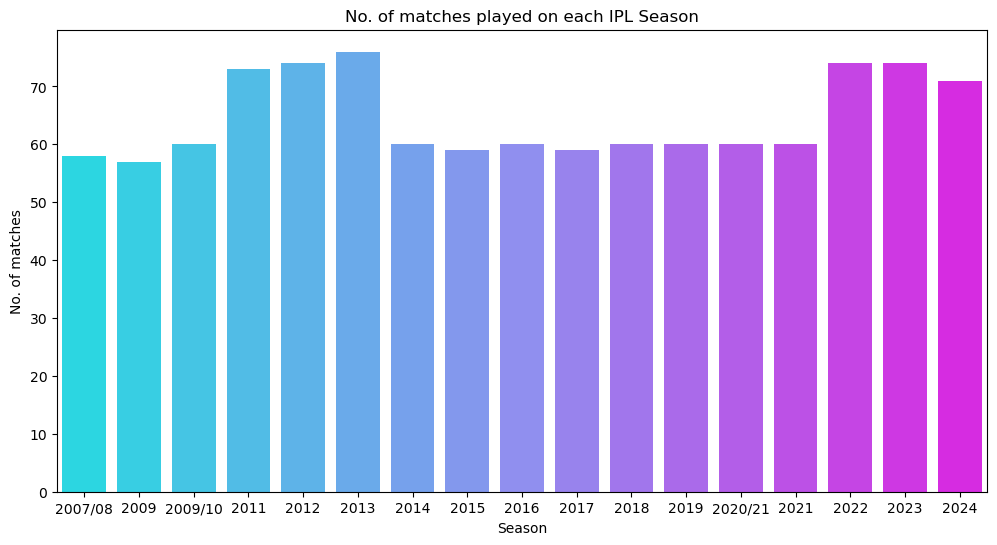

In [11]:
plt.figure(figsize=(12, 6))
sns.countplot(x='season', data=df,hue='season',legend=False, order=df['season'].value_counts().index.sort_values(), palette='cool')
plt.xlabel('Season')
plt.ylabel('No. of matches')
plt.title('No. of matches played on each IPL Season')

In [12]:
df_player_of_match = df['player_of_match'].value_counts().reset_index()[:10]

In [13]:
df_player_of_match

,player_of_match,count
0,AB de Villiers,25
1,CH Gayle,22
2,RG Sharma,19
3,V Kohli,18
4,DA Warner,18
5,MS Dhoni,17
6,YK Pathan,16
7,RA Jadeja,16
8,SR Watson,16
9,AD Russell,15


<Axes: xlabel='player_of_match', ylabel='count'>

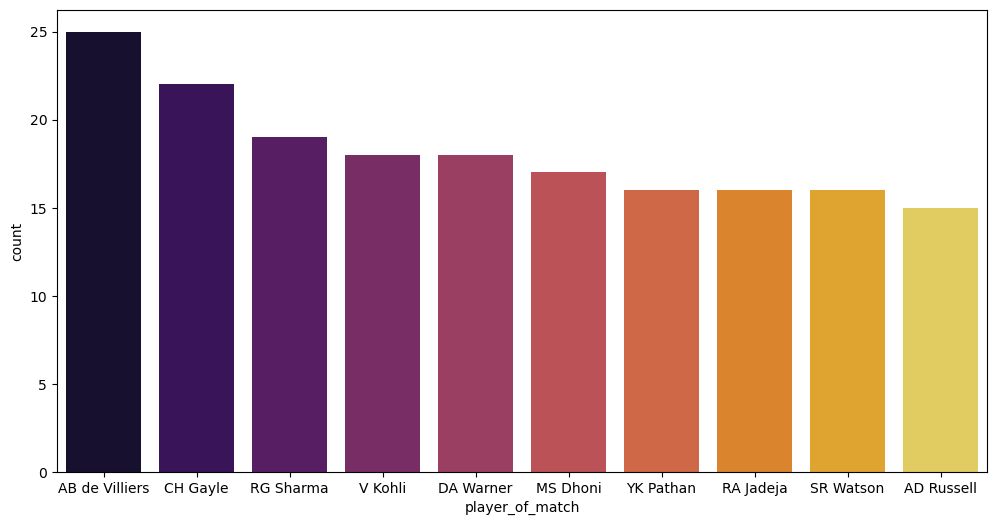

In [14]:
plt.figure(figsize=(12, 6))
sns.barplot(x='player_of_match', y='count', data=df_player_of_match, hue='player_of_match', palette='inferno')

In [15]:
df_city = df['city'].value_counts().reset_index()[:10]

In [16]:
df_city

,city,count
0,Mumbai,173
1,Kolkata,93
2,Delhi,90
3,Chennai,85
4,Hyderabad,77
5,Bangalore,65
6,Chandigarh,61
7,Jaipur,57
8,Pune,51
9,Abu Dhabi,37


Text(0, 0.5, 'Matches Count')

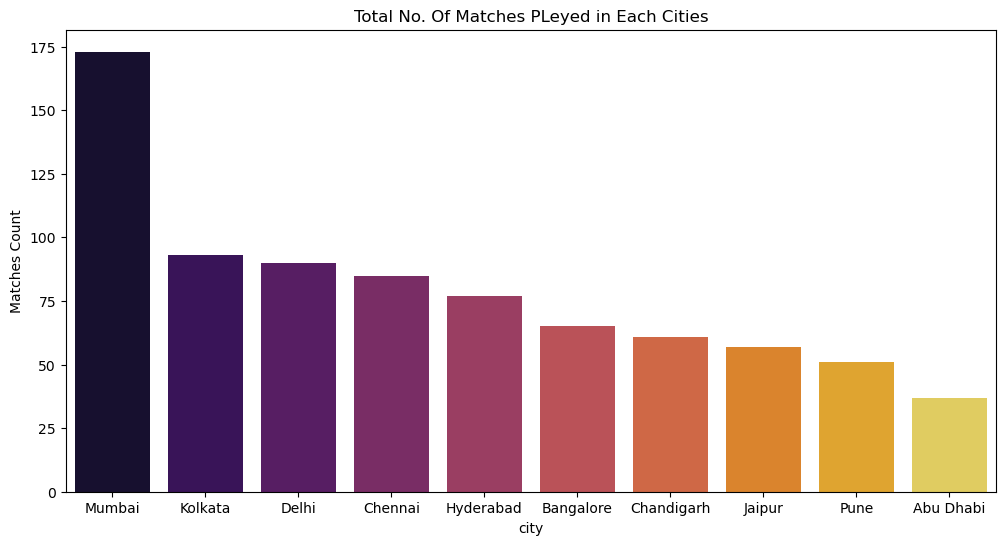

In [17]:
plt.figure(figsize=(12, 6))
sns.barplot(x='city', y='count', data=df_city, hue='city', palette='inferno')
plt.title('Total No. Of Matches PLeyed in Each Cities')
plt.ylabel('Matches Count')

In [18]:
df_matches_wins = df['winner'].value_counts().reset_index()

In [19]:
df_matches_wins

,winner,count
0,Mumbai Indians,144
1,Chennai Super Kings,138
2,Kolkata Knight Riders,131
3,Royal Challengers Bengaluru,123
4,Sunrisers Hyderabad,117
5,Delhi Capitals,115
6,Rajasthan Royals,112
7,Punjab Kings,112
8,Gujarat Titans,28
9,Rising Pune Supergiant,27


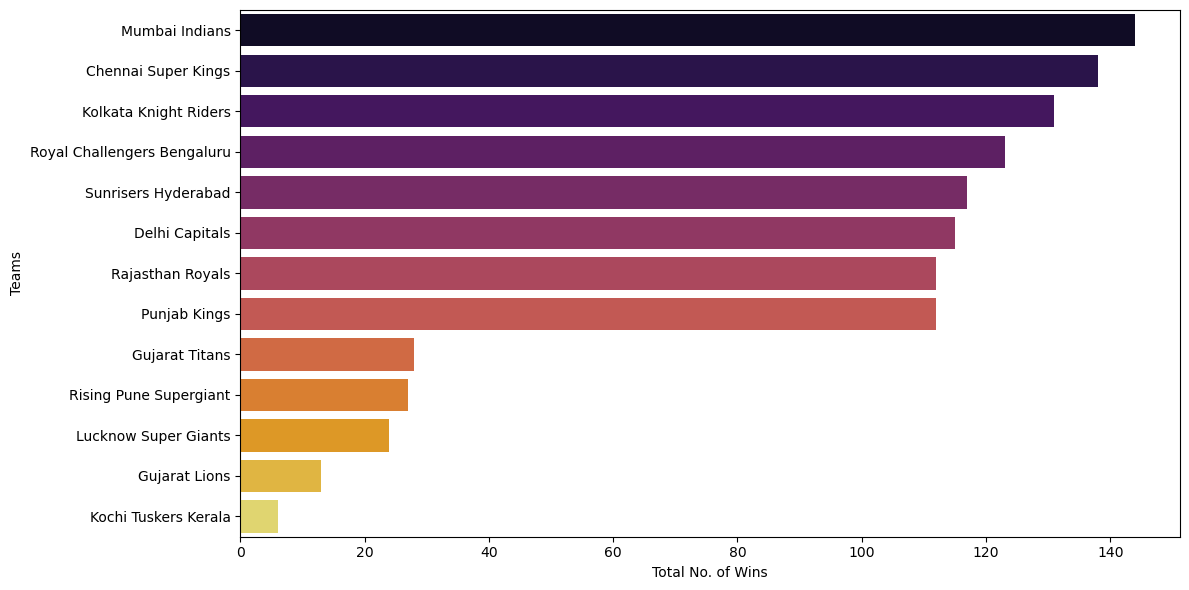

In [20]:
plt.figure(figsize=(12, 6))
sns.barplot(x='count', y='winner', data=df_matches_wins, hue='winner', palette='inferno')
plt.xlabel('Total No. of Wins')
plt.ylabel('Teams')
plt.tight_layout()

In [21]:
matches_played = df['team1'].value_counts() + df['team2'].value_counts()

In [22]:
matches_won = df['winner'].value_counts()

In [23]:
win_percentage = (matches_won/matches_played * 100).sort_values(ascending=False)[:5]

In [24]:
win_percentage

Gujarat Titans           62.222222
Chennai Super Kings      57.983193
Mumbai Indians           55.172414
Lucknow Super Giants     54.545455
Kolkata Knight Riders    52.191235
Name: count, dtype: float64

Text(0.5, 1.0, 'Top 5 teams with highest win percentage')

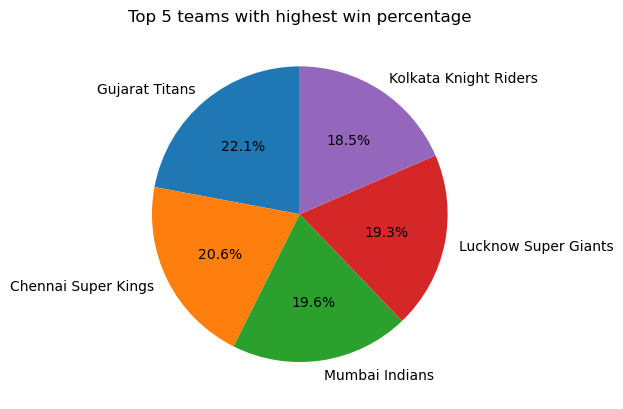

In [25]:
plt.pie(x=win_percentage.values, labels=win_percentage.index, autopct='%1.1f%%', startangle=90)
plt.title('Top 5 teams with highest win percentage')

In [26]:
df_final = df[df['match_type'] == 'Final']

In [27]:
df_final.head()

,id,season,city,date,match_type,player_of_match,venue,team1,team2,toss_winner,toss_decision,winner,result,result_margin,target_runs,target_overs,super_over,method,umpire1,umpire2
57,336040,2007/08,Mumbai,2008-06-01,Final,YK Pathan,Dr DY Patil Sports Academy,Chennai Super Kings,Rajasthan Royals,Rajasthan Royals,field,Rajasthan Royals,wickets,3.0,164.0,20.0,N,NaN,BF Bowden,RE Koertzen
114,392239,2009,Johannesburg,2009-05-24,Final,A Kumble,New Wanderers Stadium,Royal Challengers Bengaluru,Sunrisers Hyderabad,Royal Challengers Bengaluru,field,Sunrisers Hyderabad,runs,6.0,144.0,20.0,N,NaN,RE Koertzen,SJA Taufel
174,419165,2009/10,Mumbai,2010-04-25,Final,SK Raina,Dr DY Patil Sports Academy,Chennai Super Kings,Mumbai Indians,Chennai Super Kings,bat,Chennai Super Kings,runs,22.0,169.0,20.0,N,NaN,RE Koertzen,SJA Taufel
247,501271,2011,Chennai,2011-05-28,Final,M Vijay,"MA Chidambaram Stadium, Chepauk",Chennai Super Kings,Royal Challengers Bengaluru,Chennai Super Kings,bat,Chennai Super Kings,runs,58.0,206.0,20.0,N,NaN,Asad Rauf,SJA Taufel
321,548381,2012,Chennai,2012-05-27,Final,MS Bisla,"MA Chidambaram Stadium, Chepauk",Kolkata Knight Riders,Chennai Super Kings,Chennai Super Kings,bat,Kolkata Knight Riders,wickets,5.0,191.0,20.0,N,NaN,BF Bowden,SJA Taufel


In [28]:
df_final_winners = df_final['winner'].value_counts().reset_index()

In [29]:
df_final_winners

,winner,count
0,Mumbai Indians,5
1,Chennai Super Kings,5
2,Kolkata Knight Riders,3
3,Sunrisers Hyderabad,2
4,Rajasthan Royals,1
5,Gujarat Titans,1


Text(0.5, 1.0, 'IPL Final Winners')

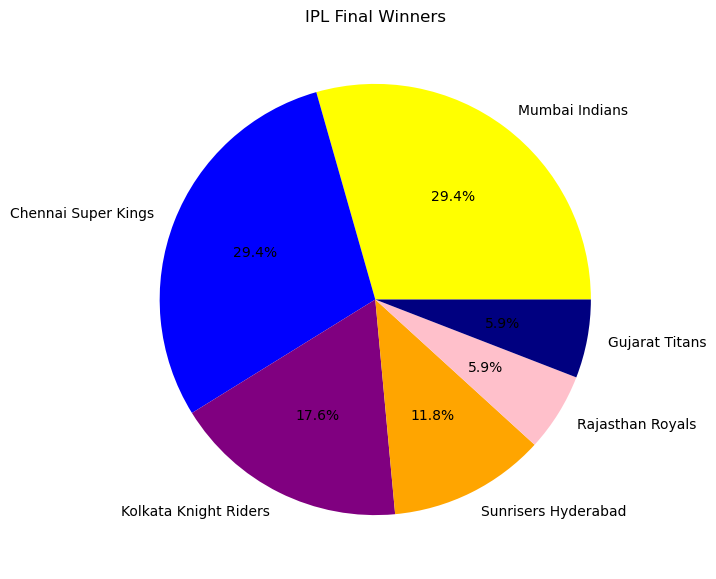

In [30]:
colors = [ 'yellow', 'blue', 'purple', 'orange', 'pink', '#000080',]
plt.figure(figsize=(7, 7))
plt.pie(x='count',labels='winner', data=df_final_winners, colors=colors, autopct='%1.1f%%')
plt.title('IPL Final Winners')

In [31]:
df.head()

,id,season,city,date,match_type,player_of_match,venue,team1,team2,toss_winner,toss_decision,winner,result,result_margin,target_runs,target_overs,super_over,method,umpire1,umpire2
0,335982,2007/08,Bangalore,2008-04-18,League,BB McCullum,M Chinnaswamy Stadium,Royal Challengers Bengaluru,Kolkata Knight Riders,Royal Challengers Bengaluru,field,Kolkata Knight Riders,runs,140.0,223.0,20.0,N,NaN,Asad Rauf,RE Koertzen
1,335983,2007/08,Chandigarh,2008-04-19,League,MEK Hussey,"Punjab Cricket Association Stadium, Mohali",Punjab Kings,Chennai Super Kings,Chennai Super Kings,bat,Chennai Super Kings,runs,33.0,241.0,20.0,N,NaN,MR Benson,SL Shastri
2,335984,2007/08,Delhi,2008-04-19,League,MF Maharoof,Feroz Shah Kotla,Delhi Capitals,Rajasthan Royals,Rajasthan Royals,bat,Delhi Capitals,wickets,9.0,130.0,20.0,N,NaN,Aleem Dar,GA Pratapkumar
3,335985,2007/08,Mumbai,2008-04-20,League,MV Boucher,Wankhede Stadium,Mumbai Indians,Royal Challengers Bengaluru,Mumbai Indians,bat,Royal Challengers Bengaluru,wickets,5.0,166.0,20.0,N,NaN,SJ Davis,DJ Harper
4,335986,2007/08,Kolkata,2008-04-20,League,DJ Hussey,Eden Gardens,Kolkata Knight Riders,Sunrisers Hyderabad,Sunrisers Hyderabad,bat,Kolkata Knight Riders,wickets,5.0,111.0,20.0,N,NaN,BF Bowden,K Hariharan


In [32]:
df_toss_decision = df['toss_decision'].value_counts().reset_index()

In [33]:
df_toss_decision

,toss_decision,count
0,field,704
1,bat,391


Text(0.5, 1.0, 'Toss Decision')

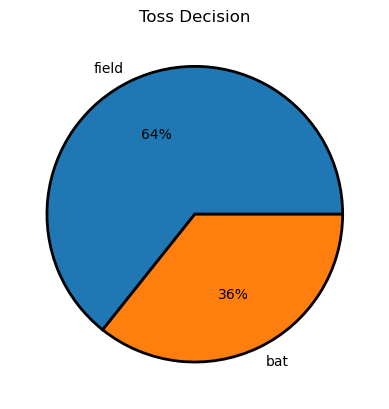

In [34]:
wedgeprops = {"edgecolor" : "black",
                      'linewidth': 2,
                      'antialiased': True}
plt.pie(x='count', labels='toss_decision', data=df_toss_decision, autopct='%1.0f%%', wedgeprops=wedgeprops)
plt.title('Toss Decision')

In [35]:
df['toss_match_winner'] = df['toss_winner'] == df['winner']

In [36]:
toss_impact = df['toss_match_winner'].value_counts(normalize=True) * 100

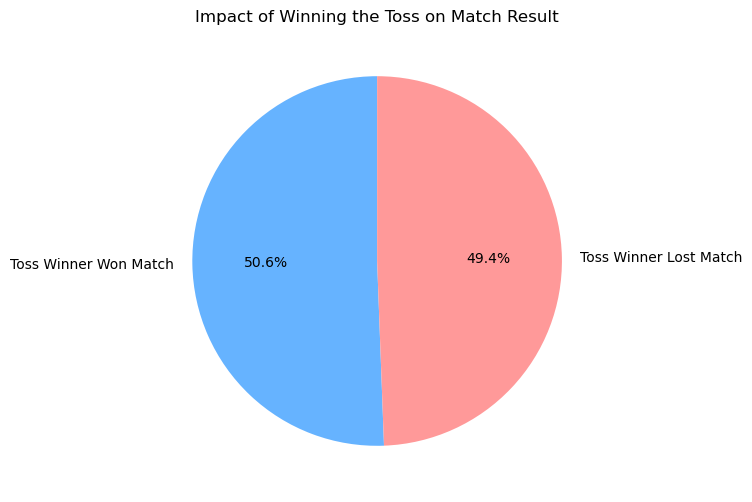

In [37]:
plt.figure(figsize=(6, 6))
plt.pie(toss_impact, labels=['Toss Winner Won Match', 'Toss Winner Lost Match'], 
        autopct='%1.1f%%', colors=['#66b3ff', '#ff9999'], startangle=90)
plt.title("Impact of Winning the Toss on Match Result")
plt.show()

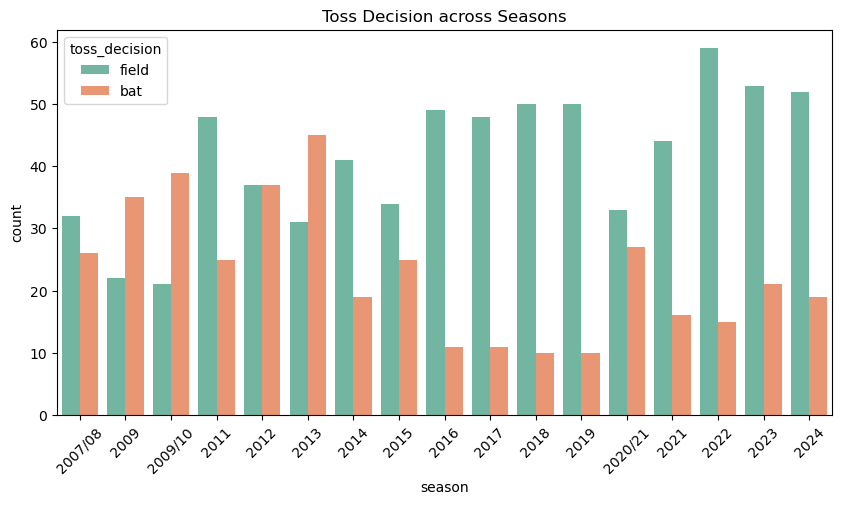

In [38]:
plt.figure(figsize=(10, 5))
sns.countplot(x='season', hue='toss_decision', data=df, palette='Set2')
plt.title('Toss Decision across Seasons')
plt.xticks(rotation=45)
plt.show()

In [39]:
df_win_result= df['result'].value_counts().reset_index()[:3]

In [40]:
df_win_result

,result,count
0,wickets,578
1,runs,498
2,tie,14


Text(0.5, 1.0, 'Win %: Batting First vs Chasing')

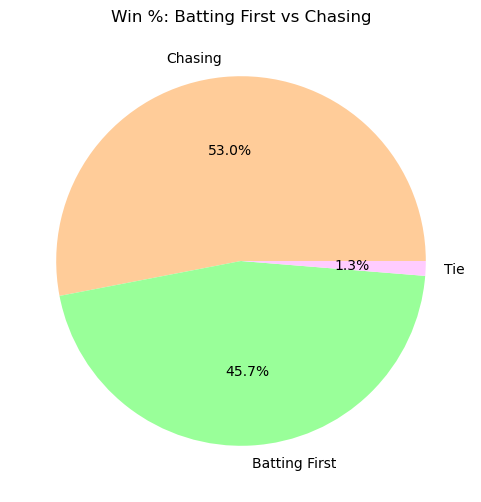

In [41]:
color = ['#ffcc99', '#99ff99', '#ffccff']
plt.figure(figsize=(6, 6))
plt.pie(x='count', labels=['Chasing', 'Batting First', 'Tie'], data = df_win_result, autopct='%1.1f%%', colors=color)
plt.title("Win %: Batting First vs Chasing")

In [43]:
df_chasing = df[df['result'] == 'wickets']

In [48]:
top_venue = df_chasing['venue'].value_counts().reset_index()[:10]

In [49]:
top_venue

,venue,count
0,Eden Gardens,45
1,Wankhede Stadium,37
2,M Chinnaswamy Stadium,36
3,Sawai Mansingh Stadium,32
4,Feroz Shah Kotla,31
5,"Rajiv Gandhi International Stadium, Uppal",28
6,"Wankhede Stadium, Mumbai",27
7,Dubai International Cricket Stadium,22
8,"Punjab Cricket Association Stadium, Mohali",20
9,Sharjah Cricket Stadium,18


In [81]:
df_venue = df['venue'].value_counts().reset_index()[:10]

In [85]:
df_venue.groupby(df['result']).value_counts()

result   venue                                       count
runs     Dubai International Cricket Stadium         46       1
         Eden Gardens                                77       1
         Punjab Cricket Association Stadium, Mohali  35       1
         Wankhede Stadium                            73       1
wickets  Feroz Shah Kotla                            60       1
         M Chinnaswamy Stadium                       65       1
         MA Chidambaram Stadium, Chepauk             48       1
         Rajiv Gandhi International Stadium, Uppal   49       1
         Sawai Mansingh Stadium                      47       1
         Wankhede Stadium, Mumbai                    45       1
Name: count, dtype: int64

In [66]:
venue_chase_stats = (df_chasing['venue'].value_counts()/df['venue'].value_counts() * 100).sort_values(ascending=False)[:5]